In [1]:
# Imports and basic options
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine, load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
print("Libraries imported. RANDOM_STATE =", RANDOM_STATE)

Libraries imported. RANDOM_STATE = 42


In [2]:
# Load Wine and initial split
breast_cancer = load_breast_cancer()
X = breast_cancer.data ###features of dataset
y = breast_cancer.target ###target
feature_names = breast_cancer.feature_names
target_names = breast_cancer.target_names

print("breast_cancer shape:", X.shape)
print("Classes:", list(target_names))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)
print("Train/Test sizes:", X_train.shape, X_test.shape)

breast_cancer shape: (569, 30)
Classes: [np.str_('malignant'), np.str_('benign')]
Train/Test sizes: (426, 30) (143, 30)


In [3]:
# This returns the DataFrame directly inside the bunch
data = load_breast_cancer(as_frame=True)
df = data.frame
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


Unpruned Accuracy: 0.9510

Classification report (Unpruned):
              precision    recall  f1-score   support

   malignant       0.93      0.94      0.94        54
      benign       0.97      0.96      0.96        89

    accuracy                           0.95       143
   macro avg       0.95      0.95      0.95       143
weighted avg       0.95      0.95      0.95       143


Confusion matrix (Unpruned):
[[51  3]
 [ 4 85]]


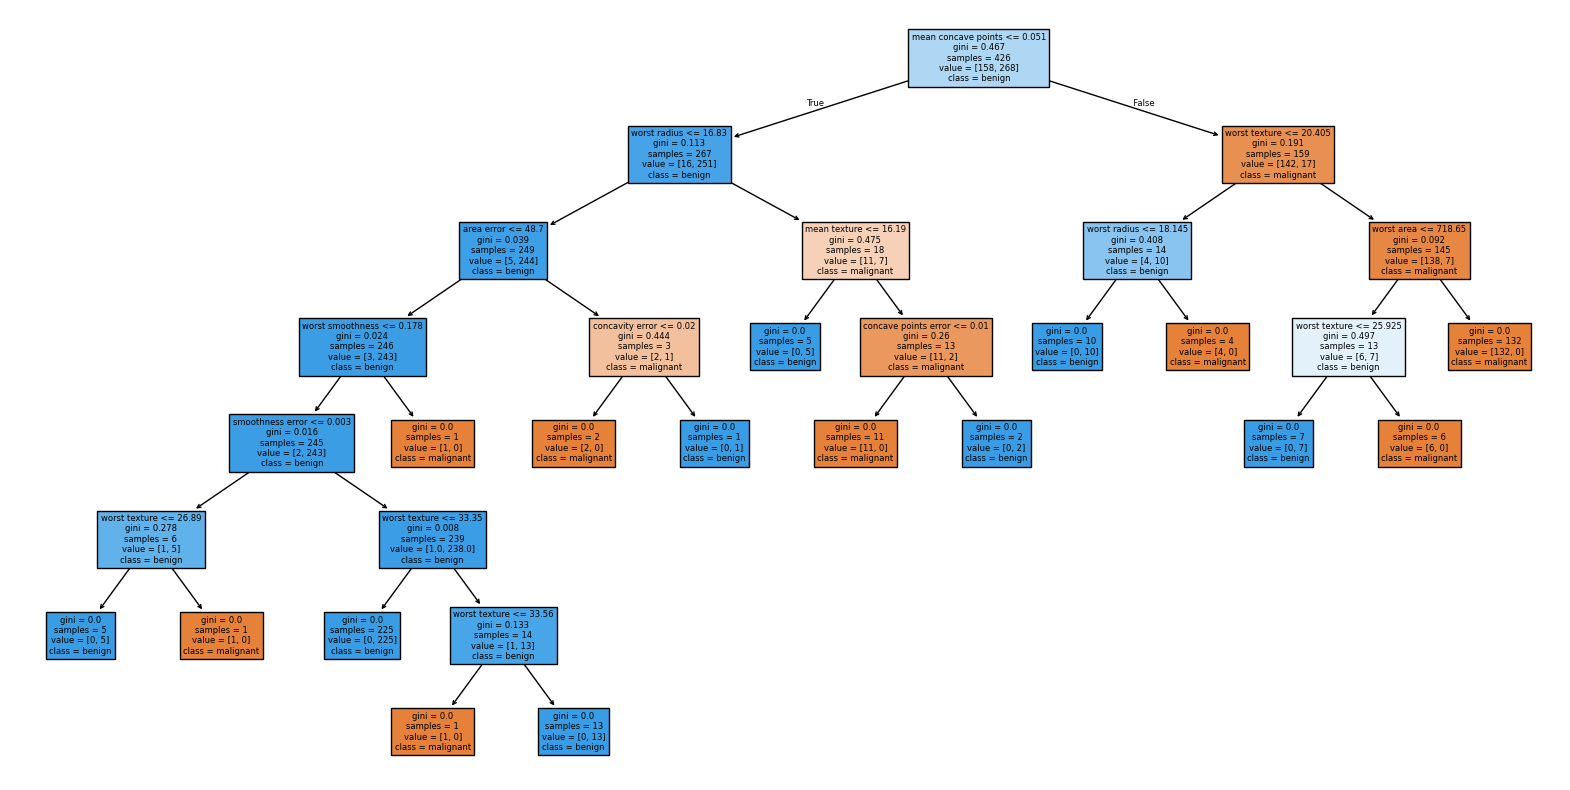

In [4]:
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt

# 1. تحميل البيانات وتحويلها لـ DataFrame
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

# 2. تقسيم البيانات (تدريب واختبار)
# بنستخدم random_state لضمان ثبات النتائج في كل مرة
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# 3. إنشاء الموديل (Unpruned)
# "Unpruned" يعني مش بنحدد max_depth ولا بنغير في الـ hyperparameters
clf_unpruned = DecisionTreeClassifier(random_state=42)

# 4. تدريب الموديل
clf_unpruned.fit(X_train, y_train)

# 5. التوقع وحساب النتائج
y_pred = clf_unpruned.predict(X_test)

# --- طباعة النتائج ---
print(f"Unpruned Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification report (Unpruned):")
print(classification_report(y_test, y_pred, target_names=data.target_names))

print("\nConfusion matrix (Unpruned):")
print(confusion_matrix(y_test, y_pred))

# 6. اختياري: رسم الشجرة عشان تشوف شكلها وهي Unpruned (هتلاقيها "عميقة" جداً)
plt.figure(figsize=(20,10))
plot_tree(clf_unpruned, filled=True, feature_names=data.feature_names, class_names=data.target_names)
plt.show()

Pruned Accuracy: 0.958

Classification report (Pruned):
              precision    recall  f1-score   support

   malignant       0.96      0.93      0.94        54
      benign       0.96      0.98      0.97        89

    accuracy                           0.96       143
   macro avg       0.96      0.95      0.96       143
weighted avg       0.96      0.96      0.96       143

Confusion matrix (Pruned):
 [[50  4]
 [ 2 87]]


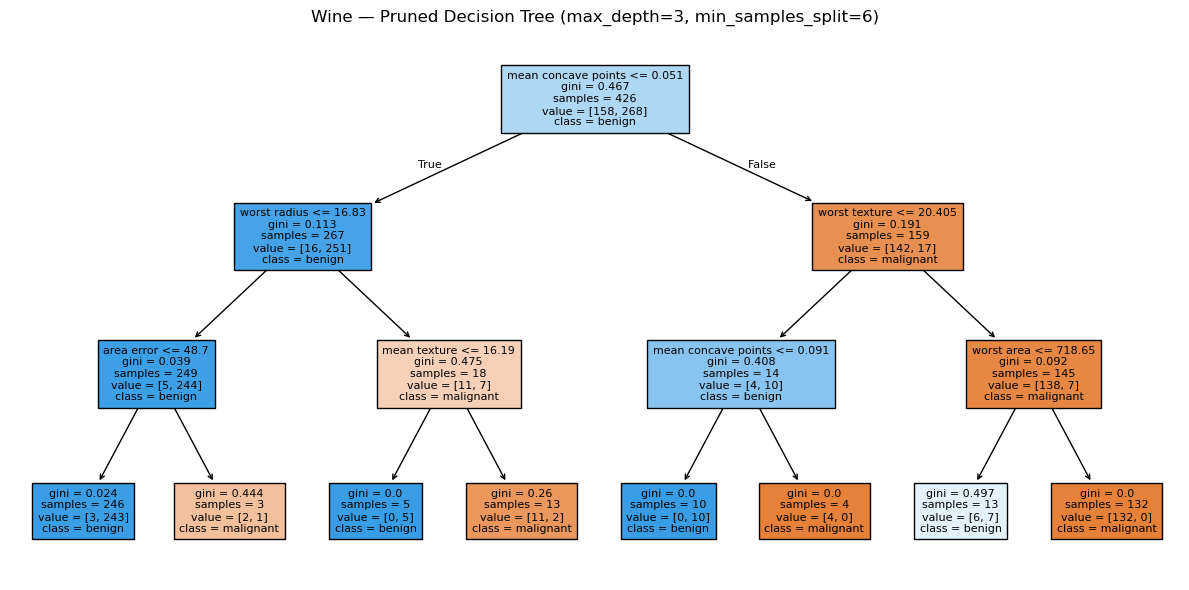

In [5]:
# Apply pruning via max_depth and min_samples_split
clf_pruned = DecisionTreeClassifier(    ### هنا استخدمت الكلاسفير الى اسمه classifier_pruned
    max_depth=3,
    min_samples_split=6,####معناها اني افصلهم لبرانش امتى لما يكون عدد الشروط دي يكون 6 او اكترانما لو اقل من كده مش هيقسمهم ل2 فروع
    random_state=RANDOM_STATE
)
clf_pruned.fit(X_train, y_train)

y_pred_p = clf_pruned.predict(X_test)
acc_p = accuracy_score(y_test, y_pred_p)
print("Pruned Accuracy:", round(acc_p, 4))
print("\nClassification report (Pruned):")
print(classification_report(y_test, y_pred_p, target_names=target_names))

cm_p = confusion_matrix(y_test, y_pred_p)
print("Confusion matrix (Pruned):\n", cm_p)

# Visualize the pruned tree
plt.figure(figsize=(12, 6))
plot_tree(
    clf_pruned,
    feature_names=feature_names,
    class_names=target_names,
    filled=True,
    rounded=False,
    fontsize=8
)
plt.title("Wine — Pruned Decision Tree (max_depth=3, min_samples_split=6)")
plt.tight_layout()
plt.show()

In [6]:
from sklearn.preprocessing import StandardScaler

# 1. تحجيم البيانات (Scaling) - خطوة احترافية
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. بناء الموديل مع بارامترات إضافية للتحكم في النمو
clf_optimized = DecisionTreeClassifier(
    max_depth=4, 
    min_samples_split=10, 
    min_samples_leaf=5, 
    criterion='entropy', # جربي entropy بدل gini أحياناً بتدي نتائج أدق
    random_state=42
)

clf_optimized.fit(X_train_scaled, y_train)
y_pred_opt = clf_optimized.predict(X_test_scaled)

print(f"Optimized Accuracy: {accuracy_score(y_test, y_pred_opt):.4f}")

Optimized Accuracy: 0.9650


Top features (Unpruned):
mean concave points     0.695937
worst texture           0.107879
worst radius            0.087737
worst area              0.034520
mean texture            0.026011
concave points error    0.017025
area error              0.012772
worst smoothness        0.009857
concavity error         0.006707
smoothness error        0.001555

Top features (Pruned):
mean concave points    0.792910
worst radius           0.064547
worst texture          0.062338
worst area             0.037771
mean texture           0.028460
area error             0.013974
mean compactness       0.000000
mean smoothness        0.000000
mean symmetry          0.000000
mean concavity         0.000000


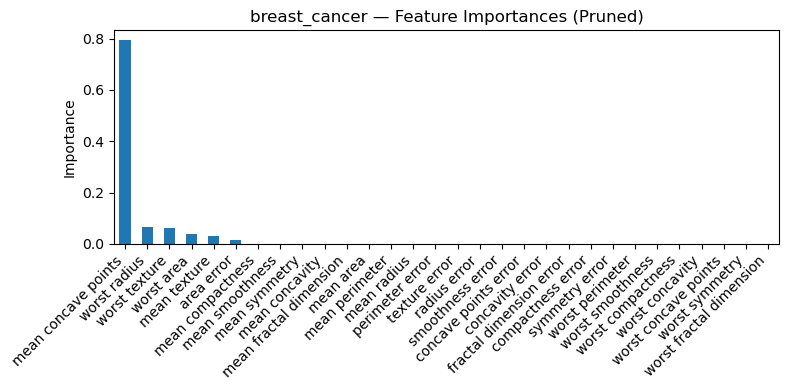

In [7]:
# Feature importances comparison
fi_unpruned = pd.Series(clf_unpruned.feature_importances_, index=feature_names).sort_values(ascending=False)
fi_pruned   = pd.Series(clf_pruned.feature_importances_ ,   index=feature_names).sort_values(ascending=False) ###الى بالازرق معناه اختارلي اعلى فيتشر

print("Top features (Unpruned):")
print(fi_unpruned.head(10).to_string())
print("\nTop features (Pruned):")
print(fi_pruned.head(10).to_string())

# Simple bar plot of importances (pruned)
plt.figure(figsize=(8, 4))
fi_pruned.plot(kind="bar")
plt.title("breast_cancer — Feature Importances (Pruned)")
plt.ylabel("Importance")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

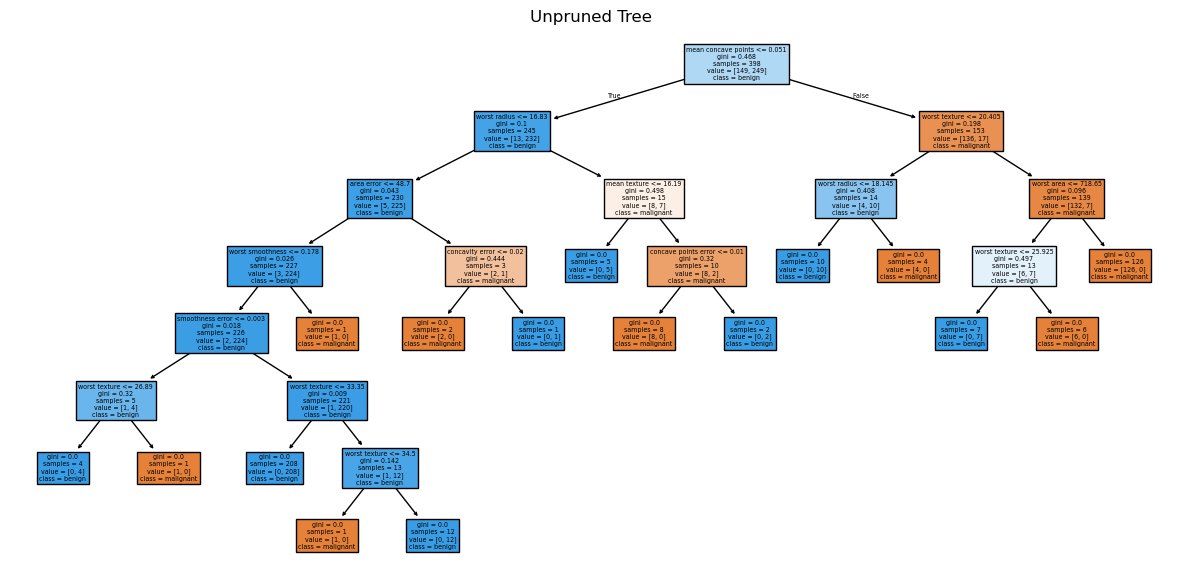

Unpruned Tree - Number of nodes: 31, Depth: 7


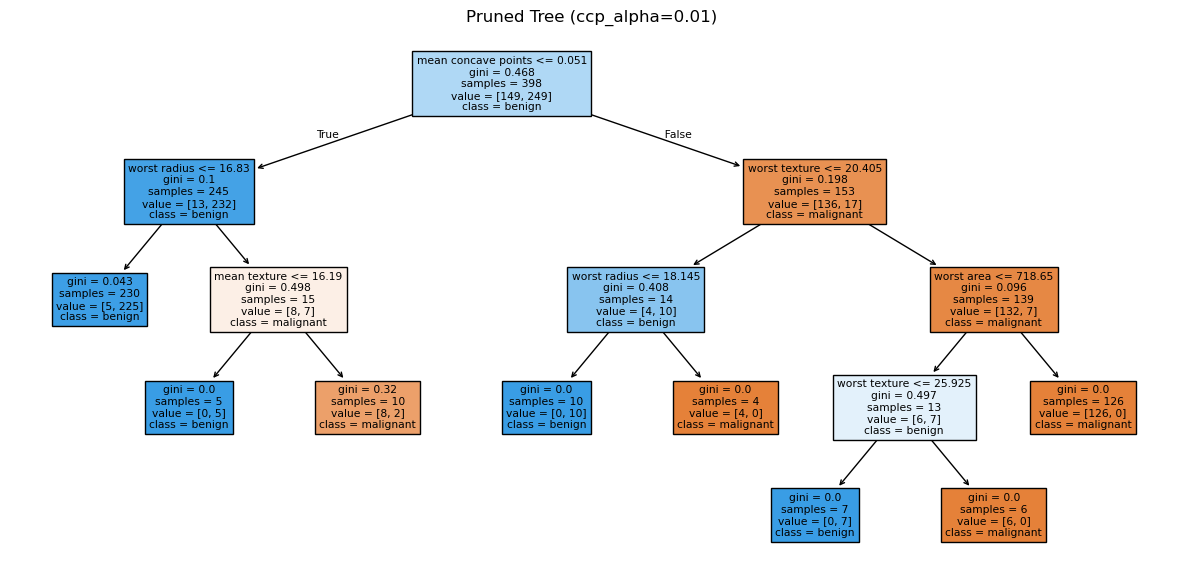

Pruned Tree - Number of nodes: 15, Depth: 4


In [8]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# ثابت للتكرار
RANDOM_STATE = 42

# تحميل البيانات
data = load_breast_cancer()
X, y = data.data, data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=RANDOM_STATE)

# 1️⃣ شجرة غير مقيدة
clf_unpruned = DecisionTreeClassifier(random_state=RANDOM_STATE)
clf_unpruned.fit(X_train, y_train)

# رسم الشجرة
plt.figure(figsize=(15,7))
plot_tree(clf_unpruned, filled=True, feature_names=data.feature_names, class_names=data.target_names)
plt.title("Unpruned Tree")
plt.show()

print(f"Unpruned Tree - Number of nodes: {clf_unpruned.tree_.node_count}, Depth: {clf_unpruned.tree_.max_depth}")

# 2️⃣ شجرة مقلمة باستخدام ccp_alpha
path = DecisionTreeClassifier(random_state=RANDOM_STATE).cost_complexity_pruning_path(X_train, y_train)
ccp_alpha = 0.01  # اختيار قيمة تجريبية للتقليم
clf_pruned = DecisionTreeClassifier(random_state=RANDOM_STATE, ccp_alpha=ccp_alpha)
clf_pruned.fit(X_train, y_train)

plt.figure(figsize=(15,7))
plot_tree(clf_pruned, filled=True, feature_names=data.feature_names, class_names=data.target_names)
plt.title(f"Pruned Tree (ccp_alpha={ccp_alpha})")
plt.show()

print(f"Pruned Tree - Number of nodes: {clf_pruned.tree_.node_count}, Depth: {clf_pruned.tree_.max_depth}")

### Observation

Before pruning, the decision tree used more features with small importance values, which indicates a more complex model that may lead to overfitting. The most important feature was **mean concave points**, followed by **worst texture** and **worst radius**.

After applying pruning, the tree relied on fewer features and some features had **zero importance**, meaning they were no longer used in the decision rules. The importance of **mean concave points** increased, showing it is the most influential feature in the model.

Overall, pruning simplified the model and improved interpretability while keeping the key predictive features.